<a href="https://colab.research.google.com/github/J4SIB/ai-course-gp/blob/main/word2vec_glove_Bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Konfiguracja środowiska


In [1]:
# Usuń wszystkie wersje scipy i numpy
!pip uninstall -y scipy numpy -q

# Zainstaluj konkretne wersje zgodne z gensim
!pip install numpy==1.26.4 scipy==1.12.0 --no-deps --force-reinstall --no-cache-dir -q

# Zainstaluj gensim w wersji 4.3.2 – stabilna i zgodna
!pip install gensim==4.3.2 --no-deps --force-reinstall --no-cache-dir -q
!pip install scikit-learn sentence-transformers matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 181.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 149.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 151.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 126.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
print("Restartuję runtime")
os.kill(os.getpid(), 9)

In [1]:
#Importy
from gensim.downloader import load
from pprint import pprint
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer, util
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd

#Załaduj model GloVe
print("Ładowanie modelu...")
glove = load("glove-wiki-gigaword-50")
print("Model GloVe załadowany.")

#Załaduj model Word2Vec
print("Ładowanie modelu...")
w2v = load("word2vec-google-news-300")
print("Model Word2Vec załadowany.")

#Załaduj model BERT
print("Ładowanie modelu...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model BERT załadowany.")

Ładowanie modelu...
[==================================================] 100.0% 66.0/66.0MB downloaded
Model GloVe załadowany.
Ładowanie modelu...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model Word2Vec załadowany.
Ładowanie modelu...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model BERT załadowany.


In [32]:
#result = w2v.most_similar(positive=['king','woman'],negative=['man'],topn=5)
#print("")
#print(result)
#result = w2v.most_similar(positive=['Paris','Poland'],negative=['France'],topn=5)
#print("Paris - France + Poland")
#print(result)
result = w2v.most_similar(positive=['Poland','metro'],negative=['Town'],topn=5)
print("")
print(result)
result = w2v.most_similar(positive=['school','adult'],negative=['student'],topn=5)
print("")
print(result)
result = w2v.most_similar(positive=['season','cold'],negative=['hot'],topn=5)
print("")
print(result)
result = w2v.most_similar(positive=['water','sand',],topn=5)
print("")
print(result)


[('Warsaw', 0.4824635088443756), ('Pomorskie', 0.45483317971229553), ('voivodships', 0.4542420208454132), ('Polish', 0.4506717920303345), ('Krakow', 0.44663524627685547)]

[('toddlers_preschoolers', 0.5414562225341797), ('adults', 0.5336923003196716), ('Adult', 0.5257500410079956), ('preschool', 0.51847904920578), ('latchkey', 0.507163941860199)]

[('winter', 0.5426986813545227), ('seasons', 0.5274052619934082), ('seaon', 0.47587457299232483), ('seson', 0.4635148346424103), ('theseason', 0.4552980065345764)]

[('seawater', 0.686552882194519), ('lagoon', 0.6381291151046753), ('oceans', 0.6335141658782959), ('lake', 0.6102173328399658), ('seawaters', 0.6060616374015808)]



 GloVe

 Word2Vec


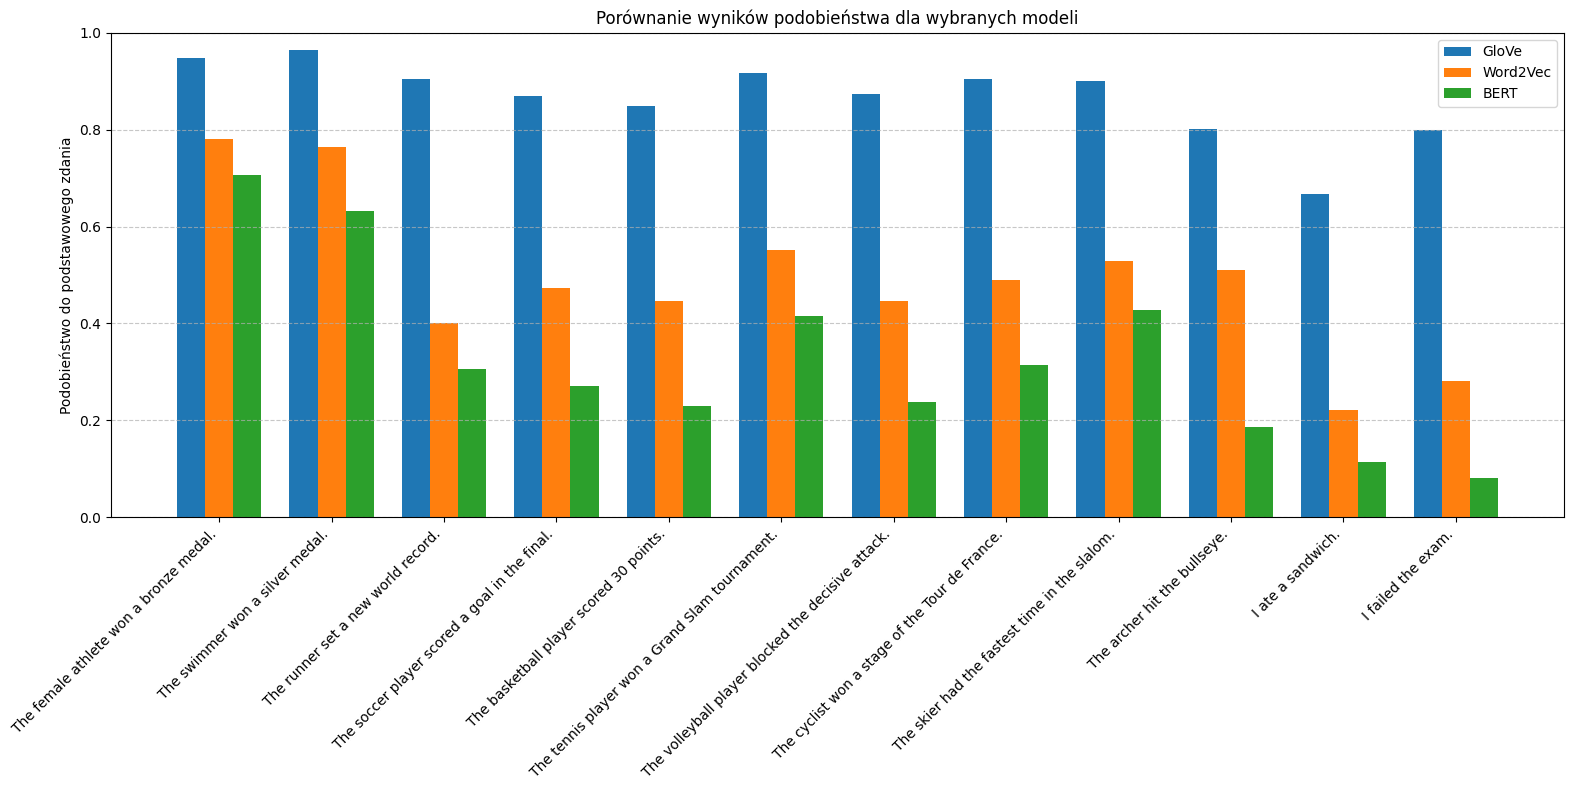

In [40]:
# Funkcja podobieństwa cosinusowego *Do uzupełnienia*
def cosine_sim(v1,v2):
  return np.dot(v1,v2) / (norm(v1) * norm(v2))

# Zdania do analizy
main_sentence = "The athlete won a gold medal at the Olympics"
other_sentences = [
    "The female athlete won a bronze medal.",
    "The swimmer won a silver medal.",
    "The runner set a new world record.",
    "The soccer player scored a goal in the final.",
    "The basketball player scored 30 points.",
    "The tennis player won a Grand Slam tournament.",
    "The volleyball player blocked the decisive attack.",
    "The cyclist won a stage of the Tour de France.",
    "The skier had the fastest time in the slalom.",
    "The archer hit the bullseye.",
    "I ate a sandwich.",
    "I failed the exam."
]
sentences = [main_sentence] + other_sentences

# GloVe *Do uzupełnienia*
print("\n GloVe")
def sentence_vec_glove(sentence):
    words = [w for w in sentence.lower().split() if w in glove]
    return np.mean([glove[w] for w in words], axis=0)

main_glove = sentence_vec_glove(main_sentence)
glove_sims = [cosine_sim(main_glove, sentence_vec_glove(s)) for s in other_sentences]

# -----------------------------
# Word2Vec *Do uzupełnienia*
print("\n Word2Vec")
def sentence_vec_w2v(sentence):
    words = [w for w in sentence.lower().split() if w in w2v]
    return np.mean([w2v[w] for w in words], axis=0)

main_w2v = sentence_vec_w2v(main_sentence)
w2v_sims = [cosine_sim(main_w2v, sentence_vec_w2v(s)) for s in other_sentences]

# -----------------------------
# BERT  *Do uzupełnienia*
embeddings = model.encode(sentences, convert_to_tensor=True)
bert_main_sentence_embedding = embeddings[0]

bert_sims = []
for i in range(1,len(sentences)):
  sim = util.cos_sim(bert_main_sentence_embedding,embeddings[i]).item()
  bert_sims.append(sim)

# -----------------------------
# Wykres porównawczy dla każdego zdania w każdym modelu
labels = other_sentences
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(16, 8))
plt.bar(x - width, glove_sims, width, label='GloVe')
plt.bar(x, w2v_sims, width, label='Word2Vec')
plt.bar(x + width, bert_sims, width, label='BERT')

plt.ylabel('Podobieństwo do podstawowego zdania')
plt.title('Porównanie wyników podobieństwa dla wybranych modeli')
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -----------------------------
# Tabela z wynikami *Do uzupełnienia*


